In [1]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df =pd.read_csv(r"c:\Users\Admin\Documents\DataSets\cars.csv",encoding='Latin')

In [3]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.shape

(11914, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

In [6]:
df.sample(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
6873,Lincoln,MKT,2016,regular unleaded,303.0,6.0,AUTOMATIC,front wheel drive,4.0,"Crossover,Luxury",Large,Wagon,24,16,61,43370
262,Nissan,350Z,2007,regular unleaded,306.0,6.0,AUTOMATIC,rear wheel drive,2.0,High-Performance,Compact,Coupe,24,17,2009,30600
4968,Nissan,Frontier,2015,regular unleaded,261.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,15,2009,35260
1755,Subaru,B9 Tribeca,2006,premium unleaded (required),250.0,6.0,AUTOMATIC,all wheel drive,4.0,Crossover,Midsize,4dr SUV,21,16,640,35895
10152,Toyota,T100,1996,regular unleaded,190.0,6.0,MANUAL,four wheel drive,2.0,NaN,Large,Extended Cab Pickup,18,15,2031,2922


In [7]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

## Handling Null Values 

In [8]:
df['Engine Fuel Type'].isnull().mean()*100

np.float64(0.02518045996306866)

In [9]:
df['Engine Fuel Type']=df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [10]:
df['Engine HP'].isnull().mean()*100

np.float64(0.5791505791505791)

<Axes: xlabel='Engine HP', ylabel='Count'>

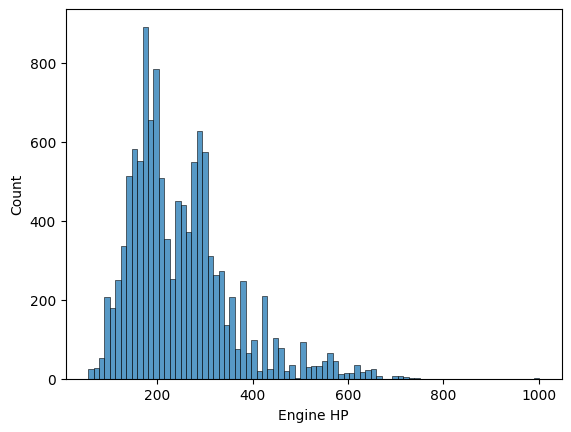

In [11]:
sns.histplot(df['Engine HP'])

In [12]:
df.groupby(df['Engine HP'].isna())['MSRP'].mean() # missing carries a signal (missing value --> lower the MSRP)

Engine HP
False    40547.195610
True     48756.014493
Name: MSRP, dtype: float64

In [13]:
df['Engine_HP_missing'] = df['Engine HP'].isna().astype(int)

In [14]:
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

In [15]:
df['Market Category'].isnull().mean()*100  # 31% of data values are missing 

np.float64(31.408427060600975)

In [16]:
df['Market Category']=df['Market Category'].fillna('Unknown')

In [17]:
df['Market Category'].value_counts()

Market Category
Unknown                                            3742
Crossover                                          1110
Flex Fuel                                           872
Luxury                                              855
Luxury,Performance                                  673
                                                   ... 
Crossover,Exotic,Luxury,High-Performance              1
Crossover,Exotic,Luxury,Performance                   1
Performance,Hybrid                                    1
Exotic,Luxury,High-Performance,Hybrid                 1
Flex Fuel,Factory Tuner,Luxury,High-Performance       1
Name: count, Length: 72, dtype: int64

In [18]:
df['Engine Cylinders'].isnull().mean()*100 # 25% of data val are missing 

np.float64(0.2518045996306866)

In [19]:
df['Engine Cylinders']=df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

In [20]:
df['Engine Cylinders'].mean()

np.float64(5.629763303676347)

<Axes: xlabel='Engine Cylinders', ylabel='Count'>

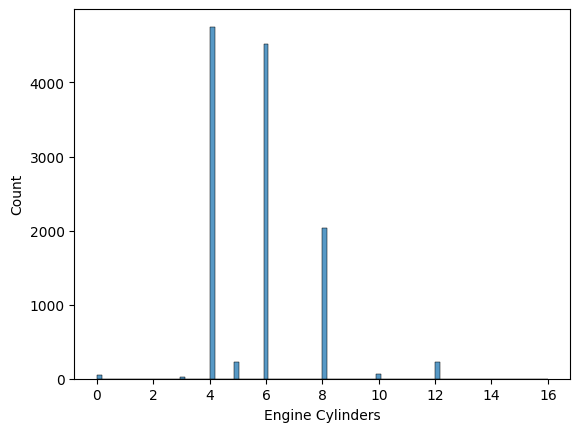

In [21]:
sns.histplot(df['Engine Cylinders'])

In [22]:
df['Number of Doors']=df['Number of Doors'].fillna(3)

In [23]:
df.isnull().sum()

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Market Category      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
Engine_HP_missing    0
dtype: int64

# MSRP


In [24]:
df['MSRP'].skew() #Msrp is highly skewed

np.float64(11.771987129334969)

<Axes: xlabel='MSRP', ylabel='Count'>

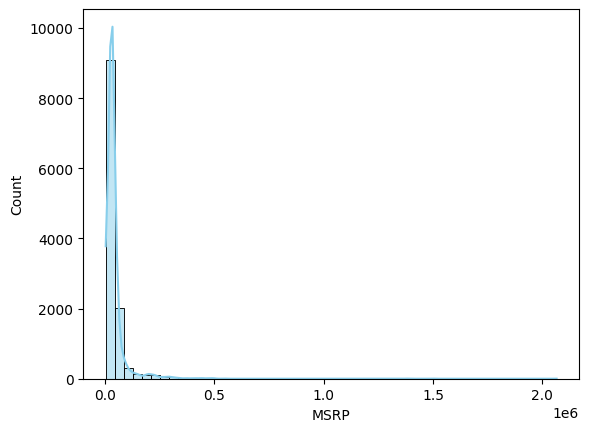

In [25]:
sns.histplot(df['MSRP'], bins=50, color='skyblue',kde=True) 

applying log transformation here for normal distribution

In [26]:
df['log_MSRP']=np.log1p(df['MSRP'])

In [27]:
df['log_MSRP'].skew() # normally distributed

np.float64(-0.917867806703907)

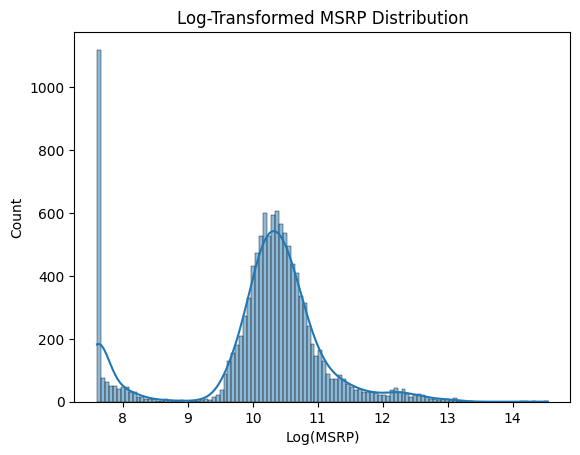

In [28]:
sns.histplot(df['log_MSRP'],kde=True)
plt.title('Log-Transformed MSRP Distribution')
plt.xlabel('Log(MSRP)')
plt.show()

# Engine HP

In [29]:
df['Engine HP'].skew() # right skewed

np.float64(1.2980337634502168)

<Axes: xlabel='Engine HP', ylabel='Count'>

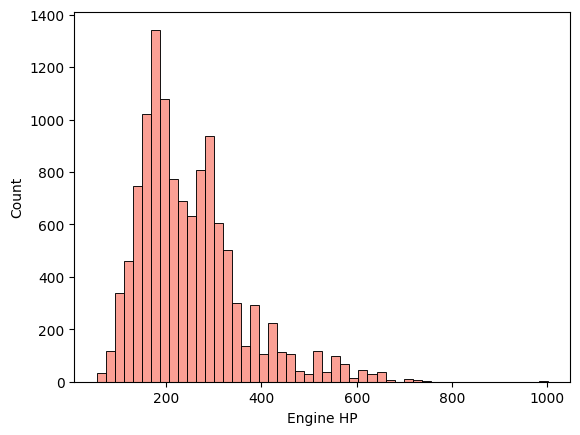

In [30]:
sns.histplot(df['Engine HP'], bins=50, color='salmon')

In [31]:
df['log_Engine_HP'] = np.log1p(df['Engine HP'])

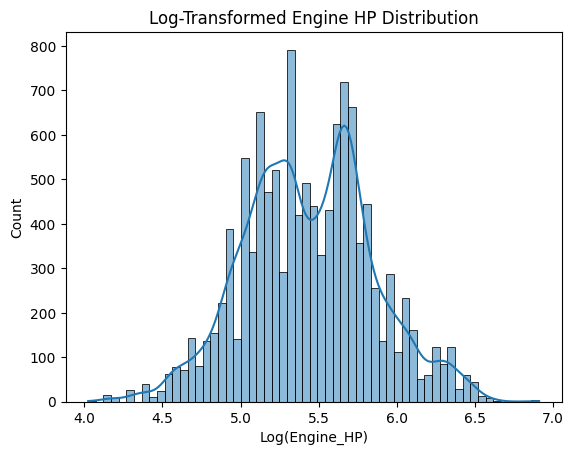

In [32]:
sns.histplot(df['log_Engine_HP'],kde=True)
plt.title('Log-Transformed Engine HP Distribution')
plt.xlabel('Log(Engine_HP)')
plt.show()

# highway MPG 
- miles travelled by a car per gallons of fuel 
- Higher MPG = better fuel efficiency

In [33]:
df['highway MPG'].skew() # highly right skew

np.float64(7.573931188779522)

<Axes: xlabel='highway MPG', ylabel='Count'>

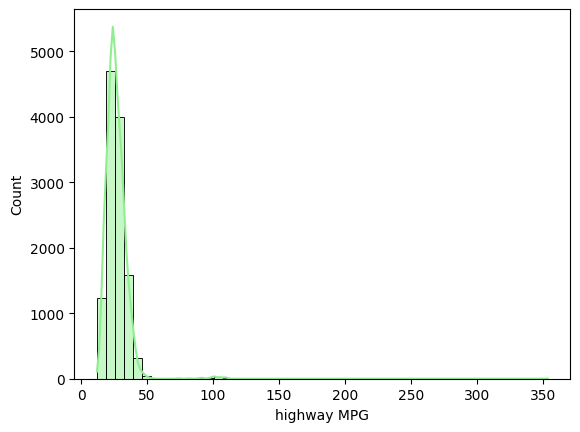

In [34]:
sns.histplot(df['highway MPG'], bins=50, color='lightgreen',kde=True)

In [35]:
with pd.option_context('display.max_rows', None):
    scrolable=df[df['highway MPG']>60][['Make', 'Model', 'Year', 'highway MPG']]
    print(scrolable)

               Make                   Model  Year  highway MPG
539            FIAT                    500e  2015          108
540            FIAT                    500e  2016          103
541            FIAT                    500e  2017          103
1119           Audi                      A6  2017          354
1680  Mercedes-Benz  B-Class Electric Drive  2015           82
1681  Mercedes-Benz  B-Class Electric Drive  2016           82
1682  Mercedes-Benz  B-Class Electric Drive  2017           82
1983      Chevrolet                 Bolt EV  2017          110
1984      Chevrolet                 Bolt EV  2017          110
3716     Volkswagen                  e-Golf  2015          105
3717     Volkswagen                  e-Golf  2015          105
3718     Volkswagen                  e-Golf  2016          105
3719     Volkswagen                  e-Golf  2016          105
4705          Honda                  Fit EV  2013          105
4706          Honda                  Fit EV  2014      

Almost every single car on this list (Nissan Leaf, Tesla Model S, Chevy Bolt, Fiat 500e, etc.) is a fully Electric Vehicle (EV). 
- Because EVs don't use liquid fuel, the EPA gives them an "MPG-e" (Miles Per Gallon Equivalent) rating.
- Values ranging from 74 to 111 are actually correct for these cars

Row 1119. It is a 2017 Audi A6 with a staggering 354 MPG.
which is a typo stretching my histplot to 354 MPG value 

In [36]:
df.loc[1119,'highway MPG']=34

In [37]:
df['highway MPG']

0        26
1        28
2        28
3        28
4        28
         ..
11909    23
11910    23
11911    23
11912    23
11913    26
Name: highway MPG, Length: 11914, dtype: int64

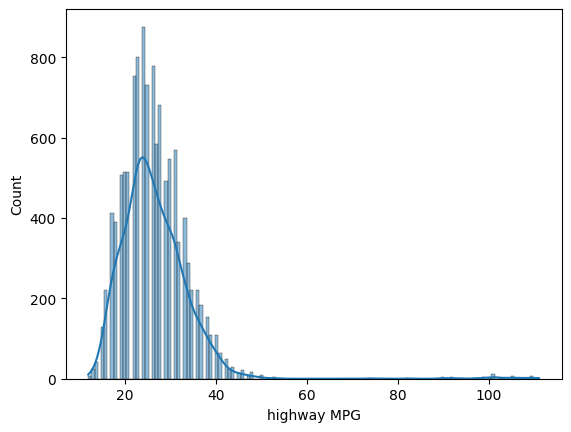

In [38]:
sns.histplot(df['highway MPG'],kde=True)
plt.show()

the right skewed that we are seeing is due to the presence of many EV's in the dataset 

In [39]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Engine_HP_missing',
       'log_MSRP', 'log_Engine_HP'],
      dtype='object')

In [40]:
df['Make'].nunique()

48

# Market Catagory 

In [41]:
df['Market Category']

0        Factory Tuner,Luxury,High-Performance
1                           Luxury,Performance
2                      Luxury,High-Performance
3                           Luxury,Performance
4                                       Luxury
                         ...                  
11909               Crossover,Hatchback,Luxury
11910               Crossover,Hatchback,Luxury
11911               Crossover,Hatchback,Luxury
11912               Crossover,Hatchback,Luxury
11913                                   Luxury
Name: Market Category, Length: 11914, dtype: object

In [42]:
market_dummies = df['Market Category'].str.get_dummies(sep=',')
df=pd.concat([df,market_dummies],axis=1)

In [43]:
market_dummies

,Crossover,Diesel,Exotic,Factory Tuner,Flex Fuel,Hatchback,High-Performance,Hybrid,Luxury,Performance,Unknown
0,0,0,0,1,0,0,1,0,1,0,0
1,0,0,0,0,0,0,0,0,1,1,0
2,0,0,0,0,0,0,1,0,1,0,0
3,0,0,0,0,0,0,0,0,1,1,0
4,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
11909,1,0,0,0,0,1,0,0,1,0,0
11910,1,0,0,0,0,1,0,0,1,0,0
11911,1,0,0,0,0,1,0,0,1,0,0
11912,1,0,0,0,0,1,0,0,1,0,0


In [44]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Engine_HP_missing',
       'log_MSRP', 'log_Engine_HP', 'Crossover', 'Diesel', 'Exotic',
       'Factory Tuner', 'Flex Fuel', 'Hatchback', 'High-Performance', 'Hybrid',
       'Luxury', 'Performance', 'Unknown'],
      dtype='object')

In [45]:
df.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
Engine_HP_missing      int64
log_MSRP             float64
log_Engine_HP        float64
Crossover              int64
Diesel                 int64
Exotic                 int64
Factory Tuner          int64
Flex Fuel              int64
Hatchback              int64
High-Performance       int64
Hybrid                 int64
Luxury                 int64
Performance            int64
Unknown                int64
dtype: object

applying min max scalar 

In [46]:
from sklearn.preprocessing import MinMaxScaler
num_cols =['log_MSRP', 'log_Engine_HP', 'Engine Cylinders',
            'highway MPG', 'city mpg', 'Popularity', 'Year', 'Number of Doors']
scaler = MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])

applying ohe/oe on cat columns 

In [47]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP', 'Engine_HP_missing',
       'log_MSRP', 'log_Engine_HP', 'Crossover', 'Diesel', 'Exotic',
       'Factory Tuner', 'Flex Fuel', 'Hatchback', 'High-Performance', 'Hybrid',
       'Luxury', 'Performance', 'Unknown'],
      dtype='object')

In [48]:
from sklearn.preprocessing import OneHotEncoder

In [49]:
cat_cols=['Make','Vehicle Size','Vehicle Style','Driven_Wheels','Transmission Type','Engine Fuel Type']
ohe = OneHotEncoder(sparse_output=False)
encoded_cat_col=ohe.fit_transform(df[cat_cols])

encoded_df=pd.DataFrame(encoded_cat_col,columns=ohe.get_feature_names_out(cat_cols))

In [50]:
df_encoded=pd.concat([df.drop(cat_cols,axis=1),encoded_df],axis=1)

In [51]:
df_encoded.head(2)

,Model,Year,Engine HP,Engine Cylinders,Number of Doors,Market Category,highway MPG,city mpg,Popularity,MSRP,...,Engine Fuel Type_diesel,Engine Fuel Type_electric,Engine Fuel Type_flex-fuel (premium unleaded recommended/E85),Engine Fuel Type_flex-fuel (premium unleaded required/E85),Engine Fuel Type_flex-fuel (unleaded/E85),Engine Fuel Type_flex-fuel (unleaded/natural gas),Engine Fuel Type_natural gas,Engine Fuel Type_premium unleaded (recommended),Engine Fuel Type_premium unleaded (required),Engine Fuel Type_regular unleaded
0,1 Series M,0.777778,335.0,0.375,0.0,"Factory Tuner,Luxury,High-Performance",0.141414,0.092308,0.692131,46135,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1 Series,0.777778,300.0,0.375,0.0,"Luxury,Performance",0.161616,0.092308,0.692131,40650,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [52]:
df_encoded['Year'].dtype

dtype('float64')

In [53]:
#to get the object dtypes
def get_dtypes(df_encoded):
    obj_col =[]
    for col in df_encoded.columns:
        if df_encoded[col].dtype =='object':
            obj_col.append(col)
    return obj_col
            
get_dtypes(df_encoded)

['Model', 'Market Category']

In [54]:
df_encoded.columns

Index(['Model', 'Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors',
       'Market Category', 'highway MPG', 'city mpg', 'Popularity', 'MSRP',
       ...
       'Engine Fuel Type_diesel', 'Engine Fuel Type_electric',
       'Engine Fuel Type_flex-fuel (premium unleaded recommended/E85)',
       'Engine Fuel Type_flex-fuel (premium unleaded required/E85)',
       'Engine Fuel Type_flex-fuel (unleaded/E85)',
       'Engine Fuel Type_flex-fuel (unleaded/natural gas)',
       'Engine Fuel Type_natural gas',
       'Engine Fuel Type_premium unleaded (recommended)',
       'Engine Fuel Type_premium unleaded (required)',
       'Engine Fuel Type_regular unleaded'],
      dtype='object', length=110)

In [55]:
feature_matrix=df_encoded.drop([ 'Model', 'MSRP', 'Engine HP','Market Category'],axis=1)

In [56]:
feature_matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Columns: 106 entries, Year to Engine Fuel Type_regular unleaded
dtypes: float64(94), int64(12)
memory usage: 9.6 MB


In [57]:
def get_dtypes(df):
    obj_col =[]
    for col in df.columns:
        if df[col].dtype =='object':
            obj_col.append(col)
    return obj_col
            
get_dtypes(feature_matrix)

[]

In [58]:
from sklearn.metrics.pairwise import cosine_similarity
sim_matrix = cosine_similarity(feature_matrix)

In [59]:
sim_matrix[900]

array([0.38175364, 0.62182098, 0.40065782, ..., 0.16154861, 0.16209056,
       0.40355983], shape=(11914,))

In [68]:
#Build the Recommendation Function using car name
df['car_name'] = df['Make'].astype(str) + ' ' + df['Model'].astype(str)
indices=pd.Series(df.index,index=df['car_name']).drop_duplicates()

def recommend_car(car_name,top_n=5):
    if car_name not in indices:
        return "Car not found in dataset."

    # 1. Get the index of the car that matches the title
    idx = indices[car_name]
    if isinstance(idx,pd.Series):
        idx = idx.iloc[0]

     # 2. Get the pairwise similarity scores of all cars with that car
    sim_scores = list(enumerate(sim_matrix[idx]))
    sim_scores = sorted(sim_scores,key=lambda x : x[1],reverse=True)

    sim_scores = sim_scores[1:top_n+1]
    car_indices = [i[0] for i in sim_scores]

    return df.iloc[car_indices][['car_name','MSRP']]

recommend_car('Porsche 911',5)



,car_name,MSRP
959,Porsche 911,98500
954,Porsche 911,96200
2005,Porsche Boxster,73500
934,Porsche 911,110800
2008,Porsche Boxster,74600


In [64]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def recommend_from_preferences(
    budget=30000, 
    vehicle_style='Sedan', 
    size='Midsize', 
    focus='balanced',         # Options: 'efficiency', 'performance', 'balanced'
    is_luxury=False, 
    transmission='AUTOMATIC',
    fuel_type='regular unleaded', 
    top_n=5
):
    """
    Takes human-friendly inputs, translates them into the model's feature space, 
    and returns the best matching cars.
    """
    
    # 1. Translate the "Focus" into actual Engine and MPG stats
    if focus == 'efficiency':
        hp, cyl, hwy_mpg, city_mpg = 130, 4, 45, 40
        is_perf = 0
    elif focus == 'performance':
        hp, cyl, hwy_mpg, city_mpg = 350, 6, 22, 16
        is_perf = 1
    else: # balanced
        hp, cyl, hwy_mpg, city_mpg = 200, 4, 30, 24
        is_perf = 0

    # 2. Build the Raw Dictionary representing the User's "Dream Car"
    user_car = {
        'Make': 'Toyota',             
        'Vehicle Size': size,
        'Vehicle Style': vehicle_style,
        'Driven_Wheels': 'front wheel drive',
        'Transmission Type': transmission,
        'Engine Fuel Type': fuel_type,
        'Year': 2017,                   
        'Engine HP': hp,
        'Engine Cylinders': cyl,
        'Number of Doors': 4,
        'highway MPG': hwy_mpg,
        'city mpg': city_mpg,
        'Popularity': 1500,           
        'MSRP': budget,
        'Engine_HP_missing': 0,
        
        # Market Dummies 
        'Crossover': 0, 'Diesel': 0, 'Exotic': 0, 'Factory Tuner': 0, 'Flex Fuel': 0,
        'Hatchback': 0, 'High-Performance': is_perf, 'Hybrid': 0, 
        'Luxury': int(is_luxury), 'Performance': is_perf, 'Unknown': 0
    }
    
    # Turn into a DataFrame
    user_df = pd.DataFrame([user_car])
    
    # 3. Applying the exact same Transformations as of my training data!

    user_df['log_MSRP'] = np.log1p(user_df['MSRP'])
    user_df['log_Engine_HP'] = np.log1p(user_df['Engine HP'])
    
    # B. MinMax Scaling 
    num_cols = ['log_MSRP', 'log_Engine_HP', 'Engine Cylinders', 'highway MPG', 
                'city mpg', 'Popularity', 'Year', 'Number of Doors']
    user_df[num_cols] = scaler.transform(user_df[num_cols])
    
    # C. One Hot Encoding (uses the `ohe` you already fit)
    cat_cols = ['Make', 'Vehicle Size', 'Vehicle Style', 'Driven_Wheels', 
                'Transmission Type', 'Engine Fuel Type']
    encoded_cats = ohe.transform(user_df[cat_cols])
    encoded_df = pd.DataFrame(encoded_cats, columns=ohe.get_feature_names_out(cat_cols))
    
    # 4. Constructing the Final "User Vector"
    # Drop the original unscaled/unencoded columns

    drop_cols = cat_cols + ['MSRP', 'Engine HP'] 
    final_user_vector = pd.concat([user_df.drop(drop_cols, axis=1), encoded_df], axis=1)
    
    # Reindex fills any missing columns with 0
    final_user_vector = final_user_vector.reindex(columns=feature_matrix.columns, fill_value=0)
    
    # 5. Calculate Cosine Similarity!
    sim_scores = cosine_similarity(final_user_vector, feature_matrix)[0]
    
    # 6. Sort and get top N matches
    sim_scores_list = list(enumerate(sim_scores))
    sorted_scores = sorted(sim_scores_list, key=lambda x: x[1], reverse=True)
    top_matches = sorted_scores[:top_n]
    top_indices = [match[0] for match in top_matches]
    
    # Return the real cars that best match!
    return df.iloc[top_indices][['Make', 'Model', 'Year', 'MSRP', 'highway MPG', 'Engine HP']]


In [70]:
df["MSRP"]

0        46135
1        40650
2        36350
3        29450
4        34500
         ...  
11909    46120
11910    56670
11911    50620
11912    50920
11913    28995
Name: MSRP, Length: 11914, dtype: int64

In [77]:
# Example 1: Someone wants a cheap, fuel-efficient commuter car (not luxury)
commuter_cars = recommend_from_preferences(
    budget=40000, 
    vehicle_style='Sedan', 
    size='Compact', 
    focus='performance', 
    is_luxury=False
)
print("--- Best Commuter Cars ---")
display(commuter_cars)

--- Best Commuter Cars ---


,Make,Model,Year,MSRP,highway MPG,Engine HP
1605,Toyota,Avalon,1.000000,41050,0.181818,268.0
1606,Toyota,Avalon,1.000000,37650,0.181818,268.0
2261,Toyota,Camry,1.000000,31370,0.181818,268.0
1602,Toyota,Avalon,0.962963,40450,0.191919,268.0
1600,Toyota,Avalon,0.962963,37050,0.191919,268.0


In [76]:
# Example 2: Someone wants a fast, luxury SUV with a high budget
luxury_suvs = recommend_from_preferences(
    budget=75000, 
    vehicle_style='4dr SUV', 
    size='Midsize', 
    focus='performance', 
    is_luxury=True
)
print("\n--- Best Luxury SUVs ---")
display(luxury_suvs)



--- Best Luxury SUVs ---


,Make,Model,Year,MSRP,highway MPG,Engine HP
11598,Volvo,XC60,0.962963,45750,0.171717,302.0
11584,Volvo,XC60,0.962963,41350,0.171717,302.0
11553,Volvo,XC60,0.925926,46750,0.181818,302.0
11563,Volvo,XC60,0.925926,45550,0.181818,302.0
11572,Volvo,XC60,0.925926,44050,0.181818,302.0
